In [1]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread("handwriting.jpeg")

In [3]:
print(type(image))

<class 'numpy.ndarray'>


In [4]:
image.shape

(820, 1599, 3)

(np.float64(-0.5), np.float64(1598.5), np.float64(819.5), np.float64(-0.5))

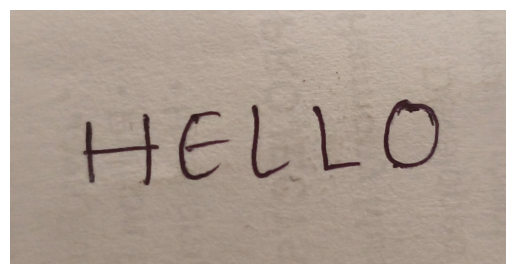

In [5]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

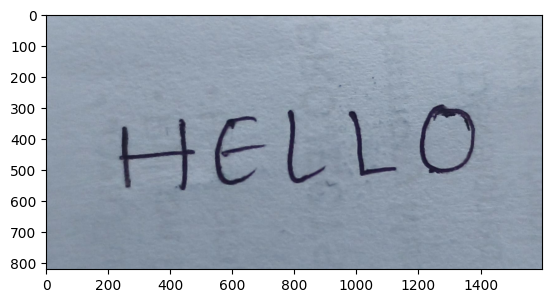

In [6]:
plt.imshow(image)

In [7]:
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

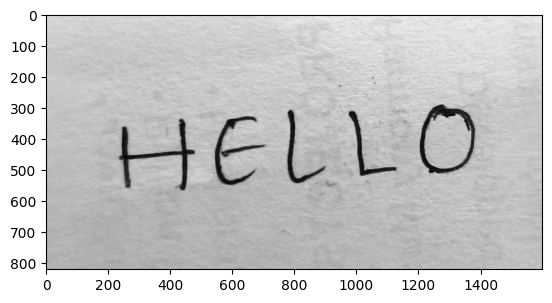

In [8]:
plt.imshow(gray,cmap="gray")

In [9]:
gray.shape

(820, 1599)

In [10]:
print(gray[0, 0])

174


In [11]:
_, threshold = cv2.threshold(
    gray,
    110,
    255,
    cv2.THRESH_BINARY
)

(np.float64(-0.5), np.float64(1598.5), np.float64(819.5), np.float64(-0.5))

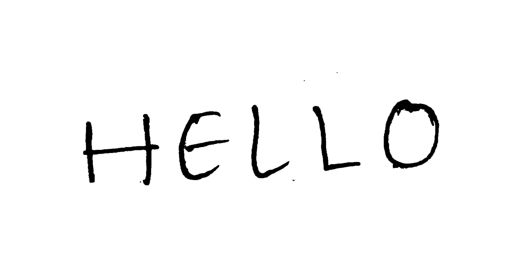

In [12]:
plt.imshow(threshold,cmap='gray')
plt.axis('off')

In [13]:
contours, hierarchy = cv2.findContours(
    threshold,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

In [14]:
print("Number of the contours : ",len(contours))

Number of the contours :  1


In [15]:
contour_image = image.copy()

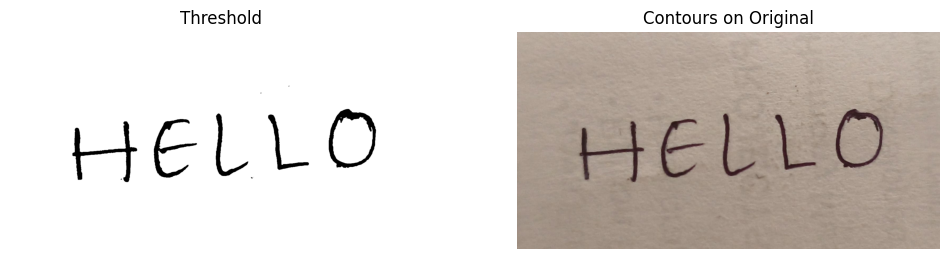

In [16]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(threshold, cmap="gray")
plt.title("Threshold")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title("Contours on Original")
plt.axis("off")
plt.show()

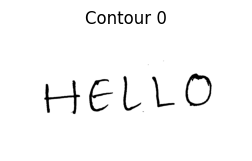

In [17]:
for i, contour in enumerate(contours):
    x, y, w, h = cv2.boundingRect(contour)
    cropped = threshold[y:y+h, x:x+w]
    plt.figure(figsize=(3, 3))
    plt.imshow(cropped, cmap="gray")
    plt.title(f"Contour {i}")
    plt.axis("off")
    plt.show()

In [18]:
resized = cv2.resize(cropped, (64, 64))

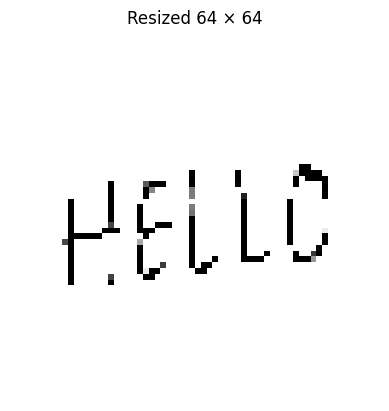

In [19]:
plt.imshow(resized, cmap="gray")
plt.title("Resized 64 × 64")
plt.axis("off");

In [20]:
template_A = np.ones((64, 64), dtype=np.uint8) * 255

In [21]:
cv2.putText(
    template_A,
    "A",
    (10, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    0,
    3
)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(64, 64), dtype=uint8)

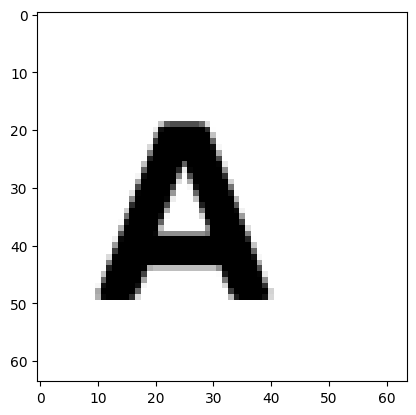

In [22]:
plt.imshow(template_A,cmap='gray')

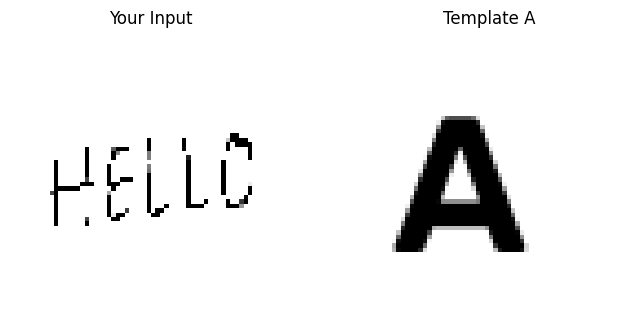

In [23]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(resized, cmap="gray")
plt.title("Your Input")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(template_A, cmap="gray")
plt.title("Template A")
plt.axis("off")
plt.show()

In [24]:
difference = np.abs(
    resized.astype(np.int16) -template_A.astype(np.int16)
)

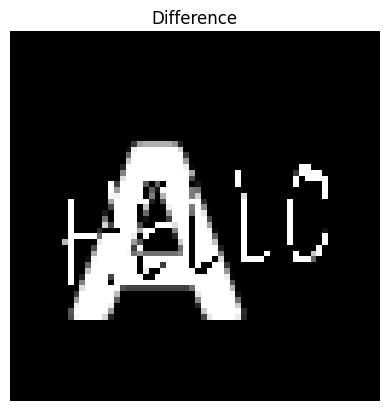

In [25]:
plt.imshow(difference, cmap="gray")
plt.title("Difference")
plt.axis("off");

In [26]:
score_A = np.sum(difference)
print("Difference score for A:", score_A)

Difference score for A: 125068


In [27]:
black_pixels = np.sum(threshold == 0)
white_pixels = np.sum(threshold == 255)
print("Black pixels:", black_pixels)
print("White pixels:", white_pixels)

Black pixels: 38670
White pixels: 1272510


In [29]:
threshold_for_contours = cv2.bitwise_not(threshold)

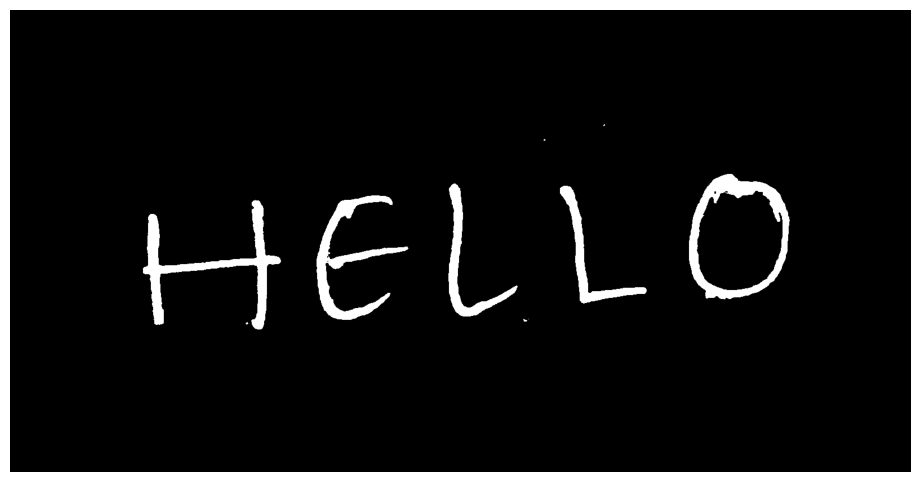

In [30]:
plt.figure(figsize=(15, 6))
plt.imshow(threshold_for_contours,cmap="gray")
plt.axis("off");

In [31]:
contours, hierarchy = cv2.findContours(
    threshold_for_contours,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
print("Contours:", len(contours))

Contours: 10


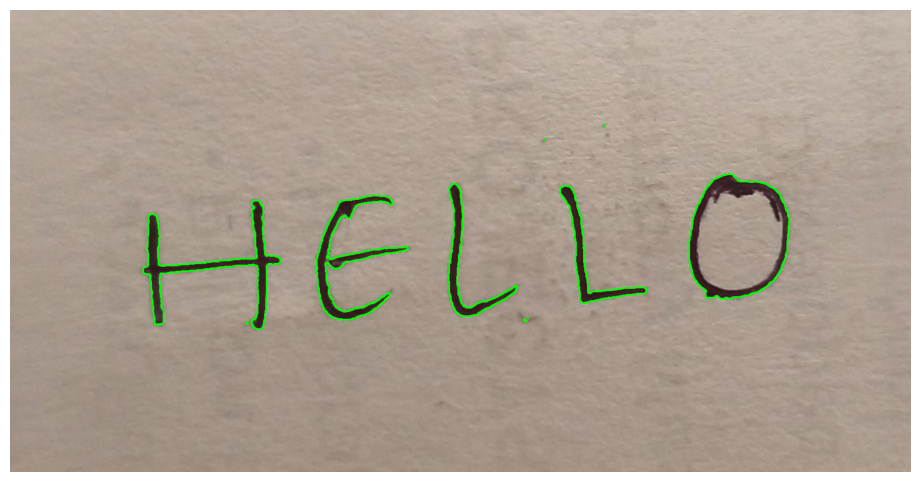

In [32]:
contour_image = image.copy()
cv2.drawContours(
    contour_image,
    contours,
    -1,
    (0, 255, 0),
    2
)
plt.figure(figsize=(15, 6))
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [33]:
boxes = []
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    boxes.append((x, y, w, h))

In [34]:
boxes = sorted(
    boxes,
    key=lambda box: box[0]
)

In [35]:
boxed_image = image.copy()
for i, (x, y, w, h) in enumerate(boxes):
    cv2.rectangle(
        boxed_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

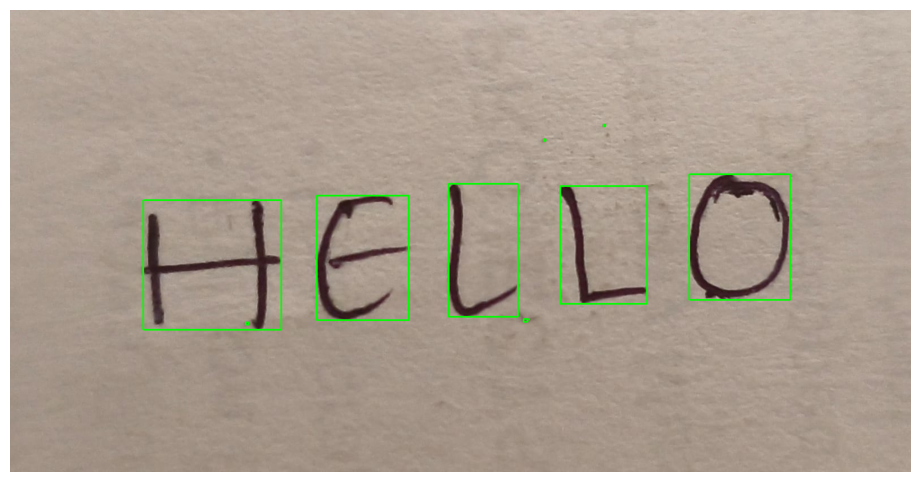

In [36]:
plt.figure(figsize=(15, 6))
plt.imshow(cv2.cvtColor(boxed_image, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [37]:
areas = []
for contour in contours:
    area = cv2.contourArea(contour)
    areas.append(area)
print("Areas:")
print(areas)
average_area = np.mean(areas)
print("Average area:", average_area)
print("Half average:", average_area / 2)

Areas:
[7.5, 0.0, 12.5, 9619.5, 7574.5, 4591.5, 4881.5, 31157.0, 3.5, 3.0]
Average area: 5785.05
Half average: 2892.525


In [38]:
for i, area in enumerate(areas):
    print(
        f"Contour {i}: {area:.2f} → "
        f"{'KEEP' if area >= average_area / 2 else 'REMOVE'}"
    )

Contour 0: 7.50 → REMOVE
Contour 1: 0.00 → REMOVE
Contour 2: 12.50 → REMOVE
Contour 3: 9619.50 → KEEP
Contour 4: 7574.50 → KEEP
Contour 5: 4591.50 → KEEP
Contour 6: 4881.50 → KEEP
Contour 7: 31157.00 → KEEP
Contour 8: 3.50 → REMOVE
Contour 9: 3.00 → REMOVE


In [39]:
min_area = average_area / 2
filtered_contours = [
    contour
    for contour in contours
    if cv2.contourArea(contour) >= min_area
]
print("Original contours:", len(contours))
print("Filtered contours:", len(filtered_contours))

Original contours: 10
Filtered contours: 5


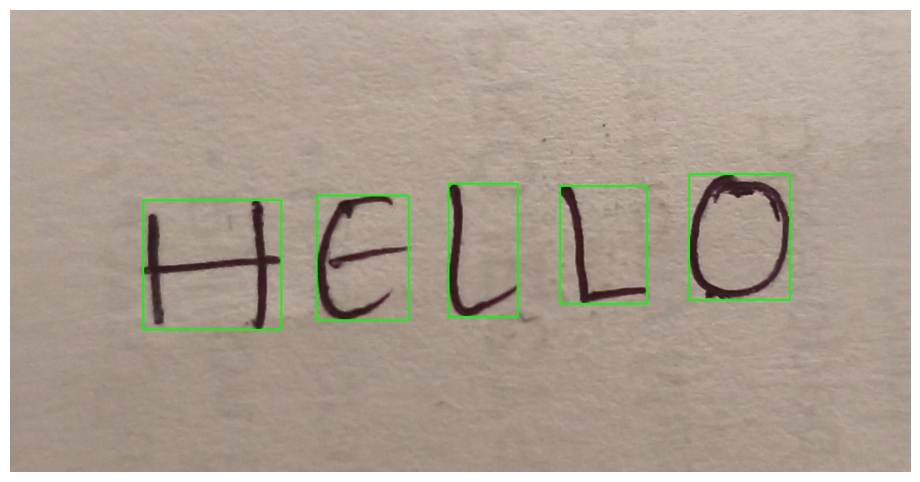

In [40]:
boxed_image = image.copy()
for i, contour in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(
        boxed_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )
plt.figure(figsize=(15, 6))
plt.imshow(
    cv2.cvtColor(boxed_image, cv2.COLOR_BGR2RGB)
)
plt.axis("off");

In [41]:
boxes = []
for contour in filtered_contours:
    x, y, w, h = cv2.boundingRect(contour)
    boxes.append((x, y, w, h))

In [42]:
boxes = sorted(
    boxes,
    key=lambda box: box[0]
)

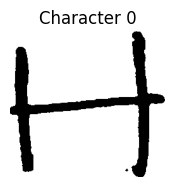

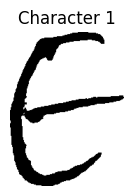

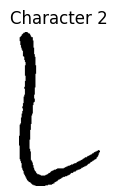

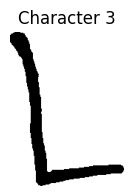

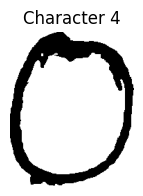

In [43]:
characters = []
for i, (x, y, w, h) in enumerate(boxes):
    character = threshold[y:y+h, x:x+w]
    characters.append(character)
    plt.figure(figsize=(2, 2))
    plt.imshow(character, cmap="gray")
    plt.title(f"Character {i}")
    plt.axis("off")
    plt.show()

In [70]:
template_A = np.ones((64, 64), dtype=np.uint8) * 255

cv2.putText(
    template_A,
    "A",
    (10, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    0,
    1
)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(64, 64), dtype=uint8)

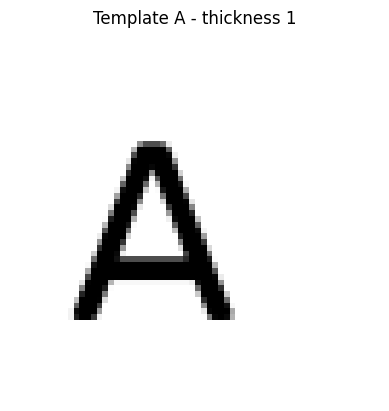

In [71]:
plt.imshow(template_A, cmap="gray")
plt.title("Template A - thickness 1")
plt.axis("off");

In [72]:
resized_characters = []

for character in characters:

    resized = cv2.resize(
        character,
        (64, 64)
    )

    resized_characters.append(resized)

In [73]:
templates = {}

for letter in ["H", "E", "L", "O"]:

    template = np.ones((64, 64), dtype=np.uint8) * 255

    cv2.putText(
        template,
        letter,
        (10, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        0,
        2
    )

    templates[letter] = template

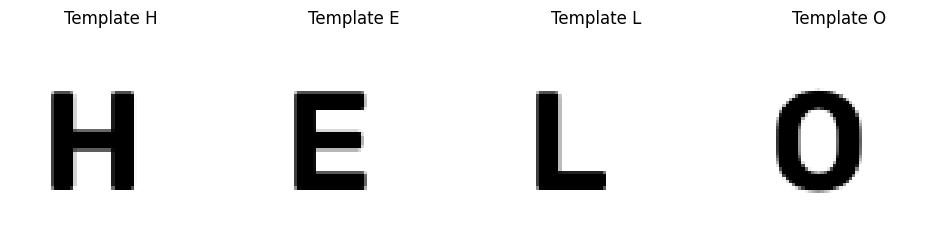

In [74]:
plt.figure(figsize=(12, 3))

for i, (letter, template) in enumerate(templates.items()):

    plt.subplot(1, 4, i + 1)
    plt.imshow(template, cmap="gray")
    plt.title(f"Template {letter}")
    plt.axis("off")

plt.show()

In [76]:
input_character = resized_characters[0]
scores = {}

for letter, template in templates.items():

    difference = np.abs(
        input_character.astype(np.int16)
        -
        template.astype(np.int16)
    )

    score = np.sum(difference)

    scores[letter] = score

print(scores)

{'H': np.int64(274823), 'E': np.int64(277153), 'L': np.int64(256602), 'O': np.int64(293437)}


The system is writer-dependent:
it performs well when the input handwriting closely matches the handwriting 
used to create the templates.